# Validação visual — mascaramento de privacidade (π) em Fonte A

Notebook de material de revisão, não parte do pipeline de produção. Valida
visualmente o mascaramento estocástico Bernoulli(π) introduzido em
`ElectionModel.fonte_a_eventos_fronteira(random_state_pi=...)`
(`src/generator/layer1_abm/model.py`, via
`src/generator/privacidade.py::mascara_sobrevivencia_pi`). Cobre dois
pontos: (1) como a série de Fonte A observada se degrada visualmente
conforme π cresce, inclusive sob fragmentação β>1; (2) a garantia central
da implementação — π nunca vaza para `eventos_desembolso` (o bruto), só
afeta o que este método retorna.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from src.generator.layer1_abm import ElectionModel

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. Cenário base: contrato ativo, β=5 (fragmentação já em jogo)

Um único `ElectionModel` roda a Fase 1 (`run()`) e a Fase 2
(`resolver_desembolso()`) uma única vez, fixando `eventos_desembolso`.
`n_agentes=100` + `beta=5` dá algumas centenas de eventos brutos
(legibilidade visual, não volume estatístico) com fragmentação já
presente, para que a interação π×β apareça nos gráficos abaixo.

In [2]:
kwargs_base = dict(
    n_agentes=100,
    prop_racional=1.0,
    recompensa=10.0,
    threshold_range=(0.0, 0.3),
    resultado_alvo=0.0,
    delta_t=50.0,
    beta=5,
    seed=7,
)

modelo = ElectionModel(**kwargs_base)
modelo.run()
modelo.resolver_desembolso()

print(f"contrato_ativado: {modelo.contrato_ativado}")
print(f"n eventos_desembolso (bruto, já fragmentado por β=5): {len(modelo.eventos_desembolso)}")

contrato_ativado: True
n eventos_desembolso (bruto, já fragmentado por β=5): 500


## 2. Por que uma instância por valor de π

`pi` é parâmetro do CONSTRUTOR de `ElectionModel` (não de
`fonte_a_eventos_fronteira`) — `self.pi` é lido dentro do método, mas
fixado na criação do modelo. Para comparar valores de π sobre o MESMO
cenário de fundo, construímos uma instância separada por valor de π,
todas com os mesmos `kwargs_base` (mesma seed de tudo mais) — isso garante
`eventos_desembolso` idêntico entre as instâncias (Fase 1/Fase 2 não usam
`self.pi` em nada, ver `CLAUDE.md`), então a única coisa que varia entre
os painéis abaixo é a máscara de π aplicada em
`fonte_a_eventos_fronteira`. Usamos o MESMO `random_state_pi` em todas as
chamadas, para que a diferença visual venha só de π, não de uma seed da
máscara diferente.

In [3]:
valores_pi = [0.0, 0.5, 0.75, 0.9, 0.95]
RANDOM_STATE_PI = 123

modelos_por_pi = {pi: ElectionModel(pi=pi, **kwargs_base) for pi in valores_pi}
for m in modelos_por_pi.values():
    m.run()
    m.resolver_desembolso()

fontes_a_por_pi = {
    pi: m.fonte_a_eventos_fronteira(random_state_pi=RANDOM_STATE_PI) for pi, m in modelos_por_pi.items()
}

## 3. Série temporal de `n_eventos` por timestep, por π

Subplots empilhados verticalmente, mesmo eixo x e mesma escala de eixo y
entre os painéis (`sharex`/`sharey`), para comparação direta — conforme π
cresce, a série deve ficar visivelmente mais esparsa (menos eventos
sobrevivem à ocultação de privacidade).

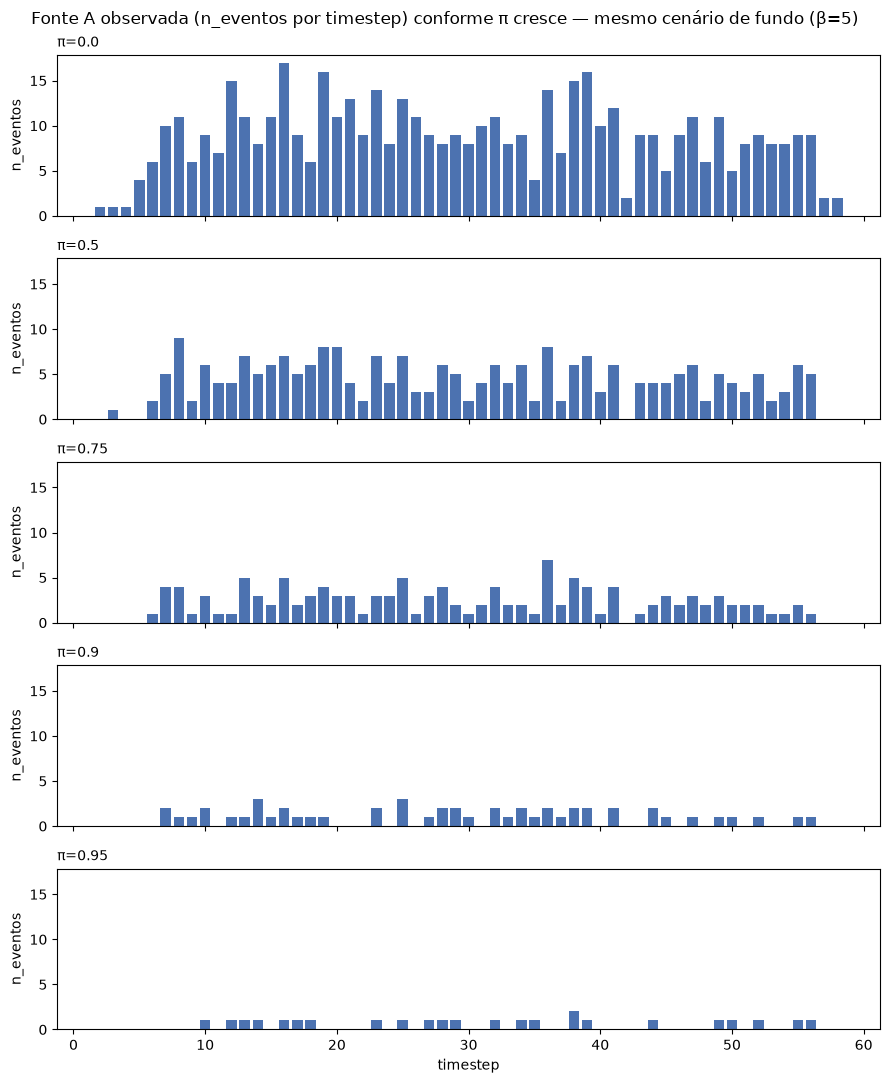

In [4]:
fig, axes = plt.subplots(len(valores_pi), 1, figsize=(9, 2.2 * len(valores_pi)), sharex=True, sharey=True)

for ax, pi in zip(axes, valores_pi):
    fonte_a = fontes_a_por_pi[pi]
    ax.bar(fonte_a["timestep"], fonte_a["n_eventos"], color="#4C72B0", width=0.8)
    ax.set_ylabel("n_eventos")
    ax.set_title(f"π={pi}", loc="left", fontsize=10)

axes[-1].set_xlabel("timestep")
fig.suptitle("Fonte A observada (n_eventos por timestep) conforme π cresce — mesmo cenário de fundo (β=5)")
fig.tight_layout()
plt.show()

**Leitura:** com π=0.0 (topo), a série reproduz exatamente o cenário de
fundo sem máscara. Conforme π cresce, as barras ficam visivelmente mais
curtas e mais esparsas — em π=0.9/0.95 (dois painéis de baixo) só uma
fração pequena dos timesteps originais ainda tem algum evento observado.
A escala de eixo y compartilhada deixa essa degradação comparável entre
os painéis, não só dentro de cada um.

## 4. Mesmo formato, agora para `volume` por timestep

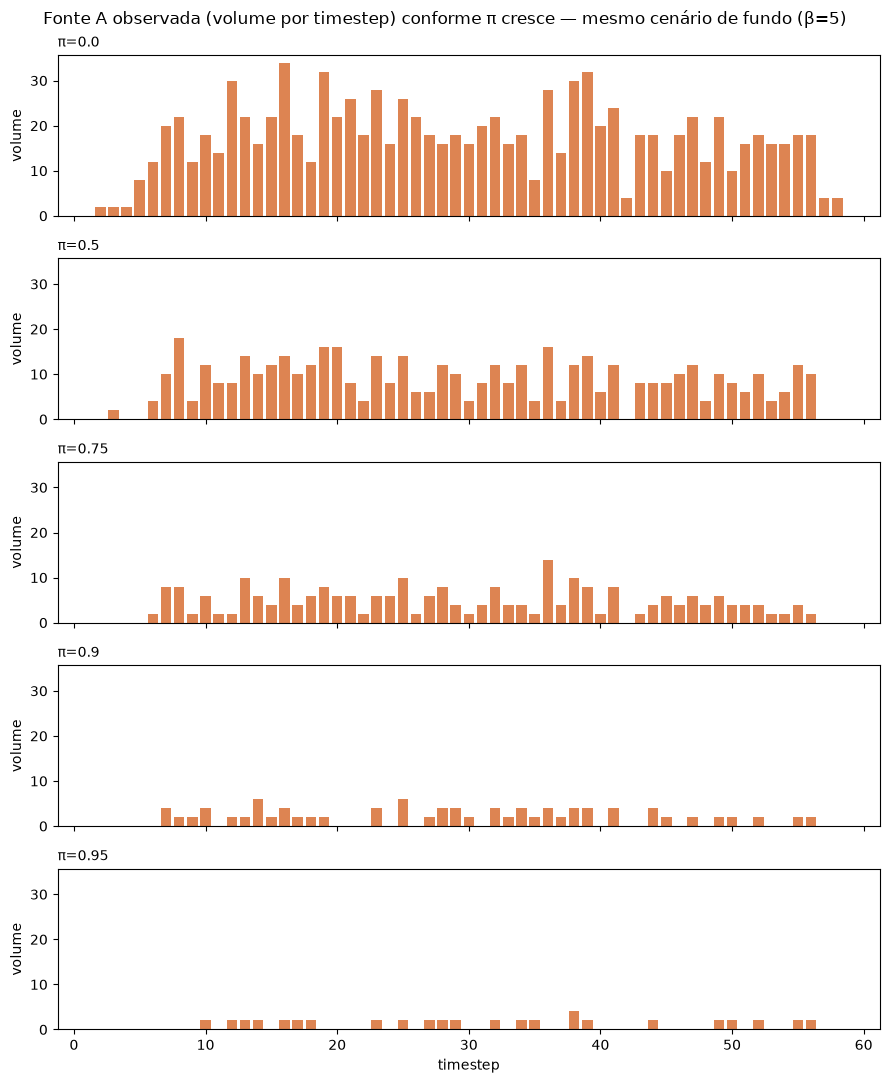

In [5]:
fig, axes = plt.subplots(len(valores_pi), 1, figsize=(9, 2.2 * len(valores_pi)), sharex=True, sharey=True)

for ax, pi in zip(axes, valores_pi):
    fonte_a = fontes_a_por_pi[pi]
    ax.bar(fonte_a["timestep"], fonte_a["volume"], color="#DD8452", width=0.8)
    ax.set_ylabel("volume")
    ax.set_title(f"π={pi}", loc="left", fontsize=10)

axes[-1].set_xlabel("timestep")
fig.suptitle("Fonte A observada (volume por timestep) conforme π cresce — mesmo cenário de fundo (β=5)")
fig.tight_layout()
plt.show()

**Leitura:** mesmo padrão de degradação do gráfico de `n_eventos` acima,
já esperado — `volume` é `n_eventos * (recompensa / beta)` (ver
docstring de `fonte_a_eventos_fronteira`), uma transformação linear por
timestep que não muda quais timesteps sobrevivem à máscara de π, só a
escala do eixo y.

## 5. Checagem numérica: fração observada vs. (1-π)

In [6]:
n_bruto = len(modelo.eventos_desembolso)

print(f"{'π':>6}  {'n_eventos_observados':>21}  {'fração observada':>17}  {'1-π esperado':>13}")
for pi in valores_pi:
    n_observado = int(fontes_a_por_pi[pi]["n_eventos"].sum())
    fracao = n_observado / n_bruto
    print(f"{pi:6.2f}  {n_observado:21d}  {fracao:17.3f}  {1 - pi:13.2f}")

     π   n_eventos_observados   fração observada   1-π esperado
  0.00                    500              1.000           1.00
  0.50                    240              0.480           0.50
  0.75                    129              0.258           0.25
  0.90                     52              0.104           0.10
  0.95                     24              0.048           0.05


**Nota sobre variância:** cada linha acima vem de uma ÚNICA amostra
Bernoulli(π) sobre `n_bruto` eventos — não uma média de várias repetições.
O desvio-padrão binomial esperado é `sqrt(π(1-π)/n_bruto)`; com
`n_bruto≈500`, isso já é pequeno o bastante para a fração ficar bem
próxima de `1-π` na maioria dos casos, mas não é garantido bater
exatamente — não é sinal de erro se um valor individual desviar um pouco
mais, especialmente para π alto (onde `n_observado` fica pequeno e a
variância relativa cresce).

## 6. Garantia central: `eventos_desembolso` (bruto) não muda com π

In [7]:
print(f"{'π':>6}  {'len(eventos_desembolso)':>24}")
for pi, m in modelos_por_pi.items():
    print(f"{pi:6.2f}  {len(m.eventos_desembolso):24d}")

tamanhos = {len(m.eventos_desembolso) for m in modelos_por_pi.values()}
assert len(tamanhos) == 1, "eventos_desembolso variou entre valores de pi -- regressao na garantia de isolamento"
print(f"\nOK: eventos_desembolso tem o MESMO tamanho ({tamanhos.pop()}) independente de π.")

     π   len(eventos_desembolso)
  0.00                       500
  0.50                       500
  0.75                       500
  0.90                       500
  0.95                       500

OK: eventos_desembolso tem o MESMO tamanho (500) independente de π.


**Leitura:** os cinco modelos (um por valor de π) produzem exatamente o
mesmo número de eventos brutos em `eventos_desembolso`, mesmo com π
variando de 0.0 a 0.95 e mascarando quase todos os eventos observáveis em
`fonte_a_eventos_fronteira()`. Isso reforça visualmente a garantia
documentada em `CLAUDE.md`/docstring do método: π mascara SOMENTE o
observável agregado retornado por `fonte_a_eventos_fronteira`, nunca o
atributo `eventos_desembolso` do modelo — que é a fonte bruta usada por
`gerar_cenario_adversarial` (tarefa futura) para alimentar Fonte B via
cópula. Fonte B é estruturalmente irredutível mesmo sob π→1
(`docs/adversary_model_draft.tex`, §"What Remains Observable Even as
π→1") — se π vazasse para `eventos_desembolso`, essa premissa seria
violada silenciosamente.